# India AQI Analysis and Prediction

**Author:** Ashish Singh  
**Program:** IBM SkillsBuild Data Analytics with AI Academic Internship (BharatCares + AICTE)

## Objective
Analyze air quality data across major Indian cities (2015–2020), uncover trends and patterns, and build machine-learning models to **predict the next-day Air Quality Index (AQI)**.

## Dataset
- **Source:** [Kaggle – Air Quality Data in India (2015-2020)](https://www.kaggle.com/datasets/rohanrao/air-quality-data-in-india)
- **File:** `city_day.csv` — daily city-level pollutant readings and AQI
- **Columns:** City, Date, PM2.5, PM10, NO, NO2, NOx, NH3, CO, SO2, O3, Benzene, Toluene, Xylene, AQI, AQI_Bucket

## 1. Imports and Configuration
All library imports are placed here. `random_state=42` is used throughout for reproducibility.

In [1]:
# ── Imports ──────────────────────────────────────────────────────────────────
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# ── Configuration ────────────────────────────────────────────────────────────
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# Plot styling
plt.rcParams.update({
    'figure.figsize': (12, 6),
    'figure.dpi': 100,
    'axes.titlesize': 14,
    'axes.labelsize': 12,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'legend.fontsize': 10,
    'figure.titlesize': 16,
})
sns.set_style('whitegrid')
sns.set_palette('viridis')

# Paths
DATA_PATH = 'data/city_day.csv'
FIGURES_DIR = 'figures/'

print("Libraries loaded successfully.")

Libraries loaded successfully.


## 2. Data Loading and Overview
Load the raw dataset and inspect its structure, data types, date range, and coverage.

In [2]:
# Load the dataset
df_raw = pd.read_csv(DATA_PATH)
print(f"Dataset shape: {df_raw.shape[0]:,} rows × {df_raw.shape[1]} columns")
print(f"\nColumn data types:\n{df_raw.dtypes}")

Dataset shape: 29,531 rows × 16 columns

Column data types:
City           object
Date           object
PM2.5         float64
PM10          float64
NO            float64
NO2           float64
NOx           float64
NH3           float64
CO            float64
SO2           float64
O3            float64
Benzene       float64
Toluene       float64
Xylene        float64
AQI           float64
AQI_Bucket     object
dtype: object


In [3]:
# First few rows
df_raw.head()

,City,Date,PM2.5,PM10,NO,NO2,NOx,NH3,CO,SO2,O3,Benzene,Toluene,Xylene,AQI,AQI_Bucket
0,Ahmedabad,2015-01-01,NaN,NaN,0.92,18.22,17.15,NaN,0.92,27.64,133.36,0.00,0.02,0.00,NaN,NaN
1,Ahmedabad,2015-01-02,NaN,NaN,0.97,15.69,16.46,NaN,0.97,24.55,34.06,3.68,5.50,3.77,NaN,NaN
2,Ahmedabad,2015-01-03,NaN,NaN,17.40,19.30,29.70,NaN,17.40,29.07,30.70,6.80,16.40,2.25,NaN,NaN
3,Ahmedabad,2015-01-04,NaN,NaN,1.70,18.48,17.97,NaN,1.70,18.59,36.08,4.43,10.14,1.00,NaN,NaN
4,Ahmedabad,2015-01-05,NaN,NaN,22.10,21.42,37.76,NaN,22.10,39.33,39.31,7.01,18.89,2.78,NaN,NaN


In [4]:
# Date range and city count
print(f"Date range : {df_raw['Date'].min()}  to  {df_raw['Date'].max()}")
print(f"Number of cities: {df_raw['City'].nunique()}")
print(f"\nCities: {', '.join(sorted(df_raw['City'].unique()))}")

Date range : 2015-01-01  to  2020-07-01
Number of cities: 26

Cities: Ahmedabad, Aizawl, Amaravati, Amritsar, Bengaluru, Bhopal, Brajrajnagar, Chandigarh, Chennai, Coimbatore, Delhi, Ernakulam, Gurugram, Guwahati, Hyderabad, Jaipur, Jorapokhar, Kochi, Kolkata, Lucknow, Mumbai, Patna, Shillong, Talcher, Thiruvananthapuram, Visakhapatnam


In [5]:
# Basic statistics
df_raw.describe().round(2)

,PM2.5,PM10,NO,NO2,NOx,NH3,CO,SO2,O3,Benzene,Toluene,Xylene,AQI
count,24933.00,18391.00,25949.00,25946.00,25346.00,19203.00,27472.00,25677.00,25509.00,23908.00,21490.00,11422.00,24850.00
mean,67.45,118.13,17.57,28.56,32.31,23.48,2.25,14.53,34.49,3.28,8.70,3.07,166.46
std,64.66,90.61,22.79,24.47,31.65,25.68,6.96,18.13,21.69,15.81,19.97,6.32,140.70
min,0.04,0.01,0.02,0.01,0.00,0.01,0.00,0.01,0.01,0.00,0.00,0.00,13.00
25%,28.82,56.26,5.63,11.75,12.82,8.58,0.51,5.67,18.86,0.12,0.60,0.14,81.00
50%,48.57,95.68,9.89,21.69,23.52,15.85,0.89,9.16,30.84,1.07,2.97,0.98,118.00
75%,80.59,149.74,19.95,37.62,40.13,30.02,1.45,15.22,45.57,3.08,9.15,3.35,208.00
max,949.99,1000.00,390.68,362.21,467.63,352.89,175.81,193.86,257.73,455.03,454.85,170.37,2049.00


In [6]:
# Missing values — percentage per column
missing_pct = (df_raw.isnull().sum() / len(df_raw) * 100).round(2)
missing_df = pd.DataFrame({
    'Column': missing_pct.index,
    'Missing Count': df_raw.isnull().sum().values,
    'Missing %': missing_pct.values
}).sort_values('Missing %', ascending=False).reset_index(drop=True)

print("Missing values per column:\n")
print(missing_df.to_string(index=False))

Missing values per column:

    Column  Missing Count  Missing %
    Xylene          18109      61.32
      PM10          11140      37.72
       NH3          10328      34.97
   Toluene           8041      27.23
   Benzene           5623      19.04
       AQI           4681      15.85
AQI_Bucket           4681      15.85
     PM2.5           4598      15.57
       NOx           4185      14.17
        O3           4022      13.62
       SO2           3854      13.05
       NO2           3585      12.14
        NO           3582      12.13
        CO           2059       6.97
      Date              0       0.00
      City              0       0.00


### Missing-Value Observations

| Column | Missing % | Decision |
|--------|-----------|----------|
| **Xylene** | ~61% | **Drop** — more than half the values are missing; imputation would be unreliable |
| PM10, NH3 | ~35-38% | **Keep & impute** — still have enough data per city for forward/back-fill |
| Toluene, Benzene | ~19-27% | **Keep & impute** |
| Other pollutants | ≤15% | **Keep & impute** |
| AQI / AQI_Bucket | ~16% | Keep for EDA where pollutants exist; **drop rows with missing AQI before modeling** |
| City, Date | 0% | No action needed |

## 3. Data Cleaning

**Strategy:**
1. Parse `Date` to datetime and sort by City, then Date.
2. Drop the `Xylene` column (61% missing — too sparse to impute reliably).
3. Impute remaining pollutant gaps **per city** using: forward-fill → back-fill → city median.
4. Clip outliers using the IQR method (values beyond 1.5×IQR are clipped, not removed).
5. Keep rows with missing AQI for EDA but flag them for removal before modeling.

### 3.1 Parse Dates and Sort

In [7]:
df = df_raw.copy()

# Parse dates
df['Date'] = pd.to_datetime(df['Date'], format='%Y-%m-%d')

# Sort by City, then Date
df = df.sort_values(['City', 'Date']).reset_index(drop=True)

print(f"Date range: {df['Date'].min().date()} to {df['Date'].max().date()}")
print(f"Data sorted by City → Date. Shape: {df.shape}")
df[['City', 'Date']].head(10)

Date range: 2015-01-01 to 2020-07-01
Data sorted by City → Date. Shape: (29531, 16)


,City,Date
0,Ahmedabad,2015-01-01
1,Ahmedabad,2015-01-02
2,Ahmedabad,2015-01-03
3,Ahmedabad,2015-01-04
4,Ahmedabad,2015-01-05
5,Ahmedabad,2015-01-06
6,Ahmedabad,2015-01-07
7,Ahmedabad,2015-01-08
8,Ahmedabad,2015-01-09
9,Ahmedabad,2015-01-10


### 3.2 Drop Xylene Column

In [8]:
print(f"Xylene missing: {df['Xylene'].isnull().sum():,} / {len(df):,} "
      f"({df['Xylene'].isnull().mean()*100:.1f}%)")
print("Decision: Drop Xylene — over 61% missing, imputation would be unreliable.\n")

df = df.drop(columns=['Xylene'])
print(f"Remaining columns ({len(df.columns)}): {list(df.columns)}")

Xylene missing: 18,109 / 29,531 (61.3%)
Decision: Drop Xylene — over 61% missing, imputation would be unreliable.

Remaining columns (15): ['City', 'Date', 'PM2.5', 'PM10', 'NO', 'NO2', 'NOx', 'NH3', 'CO', 'SO2', 'O3', 'Benzene', 'Toluene', 'AQI', 'AQI_Bucket']


### 3.3 Per-City Imputation of Pollutant Values

**Imputation strategy:** For each city's time series, we:
1. **Forward-fill** (`ffill`) — carry the last known value forward (natural for daily time series).
2. **Back-fill** (`bfill`) — fill any leading NaNs at the start of a city's series.
3. **City median** — fill any remaining gaps with the city's column median.

This is applied to all pollutant columns. We do **not** impute AQI or AQI_Bucket here — rows without AQI will be dropped before modeling.

In [9]:
# Columns to impute (pollutants only, not AQI or AQI_Bucket)
pollutant_cols = ['PM2.5', 'PM10', 'NO', 'NO2', 'NOx', 'NH3',
                  'CO', 'SO2', 'O3', 'Benzene', 'Toluene']

print("Missing BEFORE imputation:")
print(df[pollutant_cols].isnull().sum().to_string())
print()

# Per-city imputation: ffill → bfill → city median
for col in pollutant_cols:
    # Forward-fill within each city
    df[col] = df.groupby('City')[col].transform(lambda s: s.ffill())
    # Back-fill within each city
    df[col] = df.groupby('City')[col].transform(lambda s: s.bfill())
    # Fill any remaining with city median
    df[col] = df.groupby('City')[col].transform(lambda s: s.fillna(s.median()))

print("Missing AFTER imputation:")
print(df[pollutant_cols].isnull().sum().to_string())

Missing BEFORE imputation:
PM2.5       4598
PM10       11140
NO          3582
NO2         3585
NOx         4185
NH3        10328
CO          2059
SO2         3854
O3          4022
Benzene     5623
Toluene     8041



Missing AFTER imputation:


PM2.5         0
PM10       2009
NO            0
NO2           0
NOx        1169
NH3        2009
CO            0
SO2           0
O3          162
Benzene    2732
Toluene    4010


In [10]:
# Check if any pollutant NaNs remain (cities with ALL values missing for a column)
remaining_nans = df[pollutant_cols].isnull().sum()
if remaining_nans.sum() > 0:
    print("Some cities have entirely missing columns. Filling with global median.")
    for col in pollutant_cols:
        df[col] = df[col].fillna(df[col].median())
else:
    print("All pollutant columns fully imputed — no NaNs remain.")

Some cities have entirely missing columns. Filling with global median.


### 3.4 Outlier Handling (IQR Clipping)

**Approach:** For each pollutant column, compute Q1 and Q3. Values below Q1 − 1.5×IQR or above Q3 + 1.5×IQR are **clipped** (capped) to those bounds.

We clip rather than remove because:
- Extreme pollution events are real (e.g., Delhi winter smog); removing them would lose important signal.
- Clipping retains the row while limiting the influence of extreme outliers on models.

In [11]:
def clip_iqr(series, factor=1.5):
    """Clip values to [Q1 - factor*IQR, Q3 + factor*IQR]."""
    q1 = series.quantile(0.25)
    q3 = series.quantile(0.75)
    iqr = q3 - q1
    lower = q1 - factor * iqr
    upper = q3 + factor * iqr
    return series.clip(lower, upper)


clipping_report = []
for col in pollutant_cols:
    before_min, before_max = df[col].min(), df[col].max()
    df[col] = clip_iqr(df[col])
    after_min, after_max = df[col].min(), df[col].max()
    n_clipped = ((df_raw[col] if col in df_raw.columns else pd.Series()).lt(after_min).sum() +
                 (df_raw[col] if col in df_raw.columns else pd.Series()).gt(after_max).sum())
    clipping_report.append({
        'Column': col,
        'Original Min': round(before_min, 2),
        'Original Max': round(before_max, 2),
        'Clipped Min': round(after_min, 2),
        'Clipped Max': round(after_max, 2),
    })

clip_df = pd.DataFrame(clipping_report)
print("IQR Clipping Summary (pollutant columns):\n")
print(clip_df.to_string(index=False))

IQR Clipping Summary (pollutant columns):

 Column  Original Min  Original Max  Clipped Min  Clipped Max
  PM2.5          0.04        949.99         0.04       176.88
   PM10          0.01       1000.00         0.01       289.47
     NO          0.02        390.68         0.02        46.11
    NO2          0.01        362.21         0.01        71.90
    NOx          0.00        467.63         0.00        77.84
    NH3          0.01        352.89         0.01        78.13
     CO          0.00        175.81         0.00         2.97
    SO2          0.01        193.86         0.01        36.79
     O3          0.01        257.73         0.01        84.68
Benzene          0.00        455.03         0.00         6.66
Toluene          0.00        454.85         0.00        16.76


### 3.5 Cleaned Dataset Summary

In [12]:
# Summary of the cleaned dataframe
print(f"Cleaned dataset shape: {df.shape}")
print(f"\nAQI available: {df['AQI'].notna().sum():,} rows "
      f"({df['AQI'].notna().mean()*100:.1f}%)")
print(f"AQI missing:   {df['AQI'].isna().sum():,} rows "
      f"({df['AQI'].isna().mean()*100:.1f}%)")
print(f"\nRows with missing AQI will be kept for EDA but dropped before modeling.")

Cleaned dataset shape: (29531, 15)

AQI available: 24,850 rows (84.1%)
AQI missing:   4,681 rows (15.9%)

Rows with missing AQI will be kept for EDA but dropped before modeling.


In [13]:
# Final check: data types and non-null counts
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 29531 entries, 0 to 29530
Data columns (total 15 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   City        29531 non-null  object        
 1   Date        29531 non-null  datetime64[ns]
 2   PM2.5       29531 non-null  float64       
 3   PM10        29531 non-null  float64       
 4   NO          29531 non-null  float64       
 5   NO2         29531 non-null  float64       
 6   NOx         29531 non-null  float64       
 7   NH3         29531 non-null  float64       
 8   CO          29531 non-null  float64       
 9   SO2         29531 non-null  float64       
 10  O3          29531 non-null  float64       
 11  Benzene     29531 non-null  float64       
 12  Toluene     29531 non-null  float64       
 13  AQI         24850 non-null  float64       
 14  AQI_Bucket  24850 non-null  object        
dtypes: datetime64[ns](1), float64(12), object(2)
memory usage: 3.4+ MB


In [14]:
# Preview the cleaned data
df.head(10)

,City,Date,PM2.5,PM10,NO,NO2,NOx,NH3,CO,SO2,O3,Benzene,Toluene,AQI,AQI_Bucket
0,Ahmedabad,2015-01-01,73.24,141.54,0.9200,18.22,17.1500,16.54,0.920,27.640,84.6775,0.000,0.02,NaN,NaN
1,Ahmedabad,2015-01-02,73.24,141.54,0.9700,15.69,16.4600,16.54,0.970,24.550,34.0600,3.680,5.50,NaN,NaN
2,Ahmedabad,2015-01-03,73.24,141.54,17.4000,19.30,29.7000,16.54,2.975,29.070,30.7000,6.665,16.40,NaN,NaN
3,Ahmedabad,2015-01-04,73.24,141.54,1.7000,18.48,17.9700,16.54,1.700,18.590,36.0800,4.430,10.14,NaN,NaN
4,Ahmedabad,2015-01-05,73.24,141.54,22.1000,21.42,37.7600,16.54,2.975,36.785,39.3100,6.665,16.76,NaN,NaN
5,Ahmedabad,2015-01-06,73.24,141.54,45.4100,38.48,77.8375,16.54,2.975,36.785,46.5100,5.420,10.83,NaN,NaN
6,Ahmedabad,2015-01-07,73.24,141.54,46.1075,40.62,77.8375,16.54,2.975,32.280,33.4700,0.000,0.00,NaN,NaN
7,Ahmedabad,2015-01-08,73.24,141.54,46.1075,36.74,77.8375,16.54,2.975,36.785,31.8900,0.000,0.00,NaN,NaN
8,Ahmedabad,2015-01-09,73.24,141.54,29.1600,31.00,48.0000,16.54,2.975,36.785,25.7500,0.000,0.00,NaN,NaN
9,Ahmedabad,2015-01-10,73.24,141.54,29.1600,7.04,0.0000,16.54,2.975,8.290,4.5500,0.000,0.00,NaN,NaN


In [15]:
# Save a reference to the cleaned dataframe for downstream use
df_clean = df.copy()
print(f"df_clean saved — {df_clean.shape[0]:,} rows × {df_clean.shape[1]} columns, ready for EDA.")

df_clean saved — 29,531 rows × 15 columns, ready for EDA.


---
## 4. Exploratory Data Analysis

Visualize the cleaned data to understand AQI patterns across cities, time, and pollutants. We use the full cleaned dataset (including rows with missing AQI where pollutant data exists).

### 4.1 City-wise Average AQI Ranking

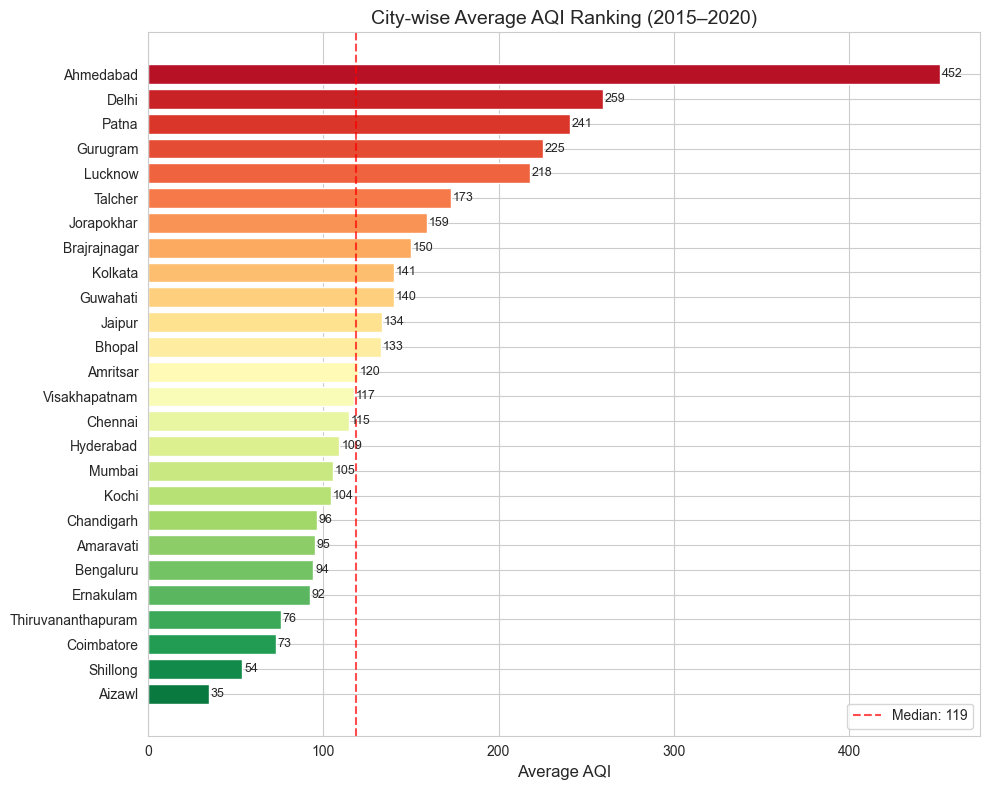

In [16]:
# City-wise average AQI (only rows where AQI is available)
city_aqi = (df_clean.dropna(subset=['AQI'])
            .groupby('City')['AQI']
            .mean()
            .sort_values(ascending=True))

fig, ax = plt.subplots(figsize=(10, 8))
bars = ax.barh(city_aqi.index, city_aqi.values, color=sns.color_palette('RdYlGn_r', len(city_aqi)))
ax.set_xlabel('Average AQI')
ax.set_title('City-wise Average AQI Ranking (2015–2020)')
ax.axvline(x=city_aqi.median(), color='red', linestyle='--', alpha=0.7, label=f'Median: {city_aqi.median():.0f}')
ax.legend()

# Add value labels
for bar, val in zip(bars, city_aqi.values):
    ax.text(val + 1, bar.get_y() + bar.get_height()/2, f'{val:.0f}',
            va='center', fontsize=9)

plt.tight_layout()
plt.savefig('figures/city_aqi_ranking.png', dpi=150, bbox_inches='tight')
plt.show()

**Takeaway:** Ahmedabad, Delhi, and Patna consistently rank among the most polluted cities, while Aizawl, Shillong, and Coimbatore have the cleanest air — reflecting the well-known North-South pollution divide in India.

### 4.2 Yearly AQI Trend

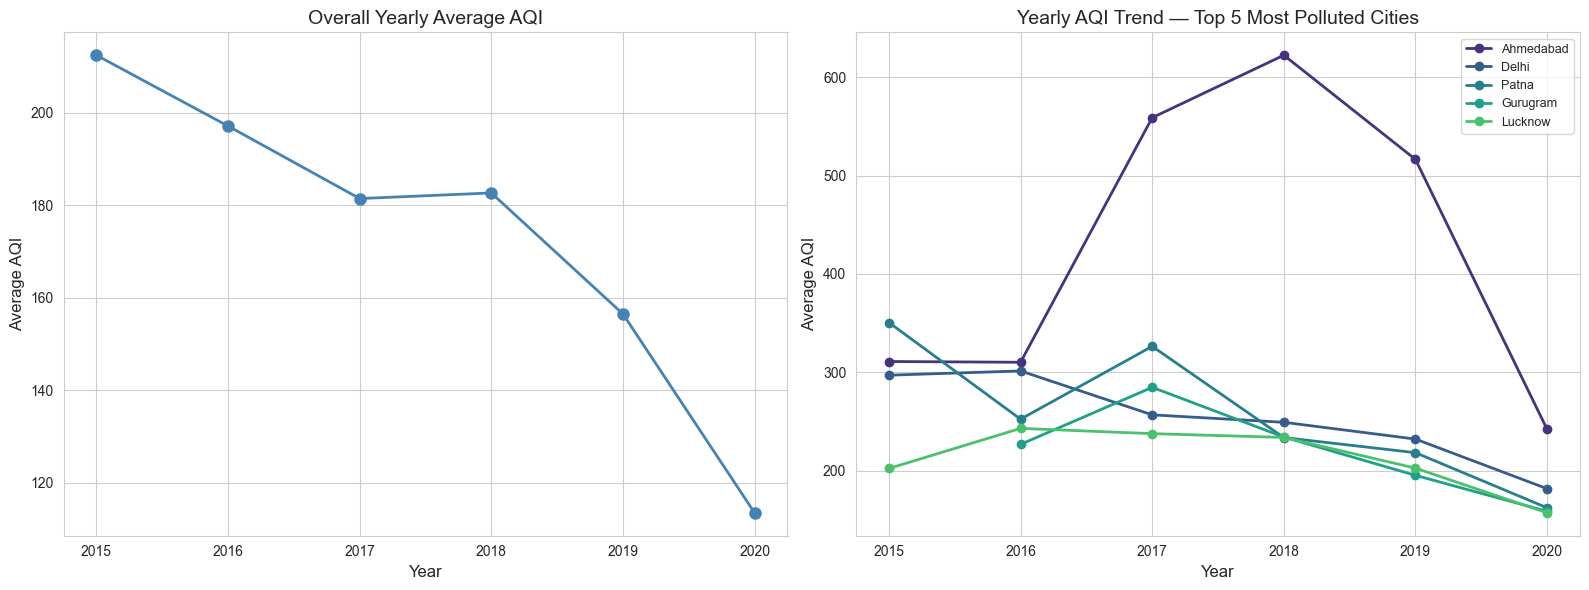

In [17]:
# Overall yearly trend
df_aqi = df_clean.dropna(subset=['AQI']).copy()
df_aqi['Year'] = df_aqi['Date'].dt.year

yearly_overall = df_aqi.groupby('Year')['AQI'].mean()

# Top 5 most polluted cities
top5_cities = (df_aqi.groupby('City')['AQI'].mean()
               .nlargest(5).index.tolist())

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Left: Overall trend
axes[0].plot(yearly_overall.index, yearly_overall.values, 'o-', linewidth=2,
             markersize=8, color='steelblue')
axes[0].set_xlabel('Year')
axes[0].set_ylabel('Average AQI')
axes[0].set_title('Overall Yearly Average AQI')
axes[0].set_xticks(yearly_overall.index)

# Right: Top 5 cities
for city in top5_cities:
    city_data = df_aqi[df_aqi['City'] == city].groupby('Year')['AQI'].mean()
    axes[1].plot(city_data.index, city_data.values, 'o-', linewidth=2,
                 markersize=6, label=city)
axes[1].set_xlabel('Year')
axes[1].set_ylabel('Average AQI')
axes[1].set_title('Yearly AQI Trend — Top 5 Most Polluted Cities')
axes[1].set_xticks(yearly_overall.index)
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.savefig('figures/yearly_aqi_trend.png', dpi=150, bbox_inches='tight')
plt.show()

**Takeaway:** There is a noticeable dip in average AQI in 2020, largely attributable to the COVID-19 lockdown. The top polluted cities show greater year-to-year variation, but consistently stay above the national average.

### 4.3 Monthly / Seasonal AQI Pattern

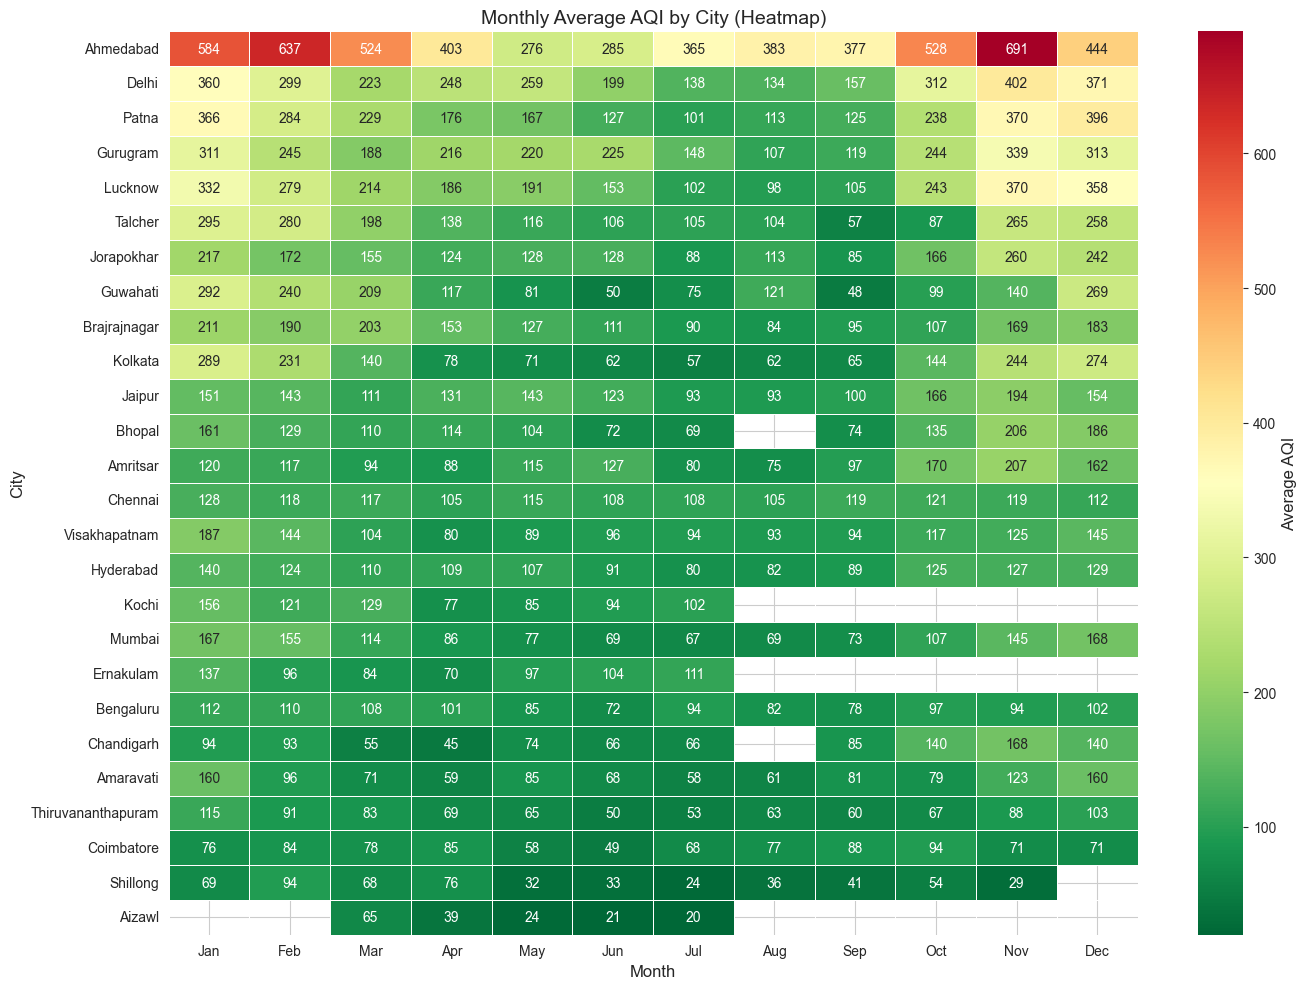

In [18]:
# Monthly average AQI heatmap (City × Month)
df_aqi['Month'] = df_aqi['Date'].dt.month

# Pivot: city vs month
monthly_city = df_aqi.pivot_table(values='AQI', index='City', columns='Month', aggfunc='mean')

# Sort cities by overall mean AQI for better visual
monthly_city = monthly_city.loc[monthly_city.mean(axis=1).sort_values(ascending=False).index]

fig, ax = plt.subplots(figsize=(14, 10))
sns.heatmap(monthly_city, annot=True, fmt='.0f', cmap='RdYlGn_r',
            linewidths=0.5, ax=ax, cbar_kws={'label': 'Average AQI'})
ax.set_xlabel('Month')
ax.set_ylabel('City')
ax.set_title('Monthly Average AQI by City (Heatmap)')
ax.set_xticklabels(['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
                     'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])
plt.tight_layout()
plt.savefig('figures/monthly_seasonal_aqi.png', dpi=150, bbox_inches='tight')
plt.show()

**Takeaway:** Winter months (November–January) see the worst air quality across most North Indian cities, driven by temperature inversions, crop burning, and stagnant air. Southern and northeastern cities remain relatively clean year-round.

### 4.4 Pollutant Correlation Heatmap

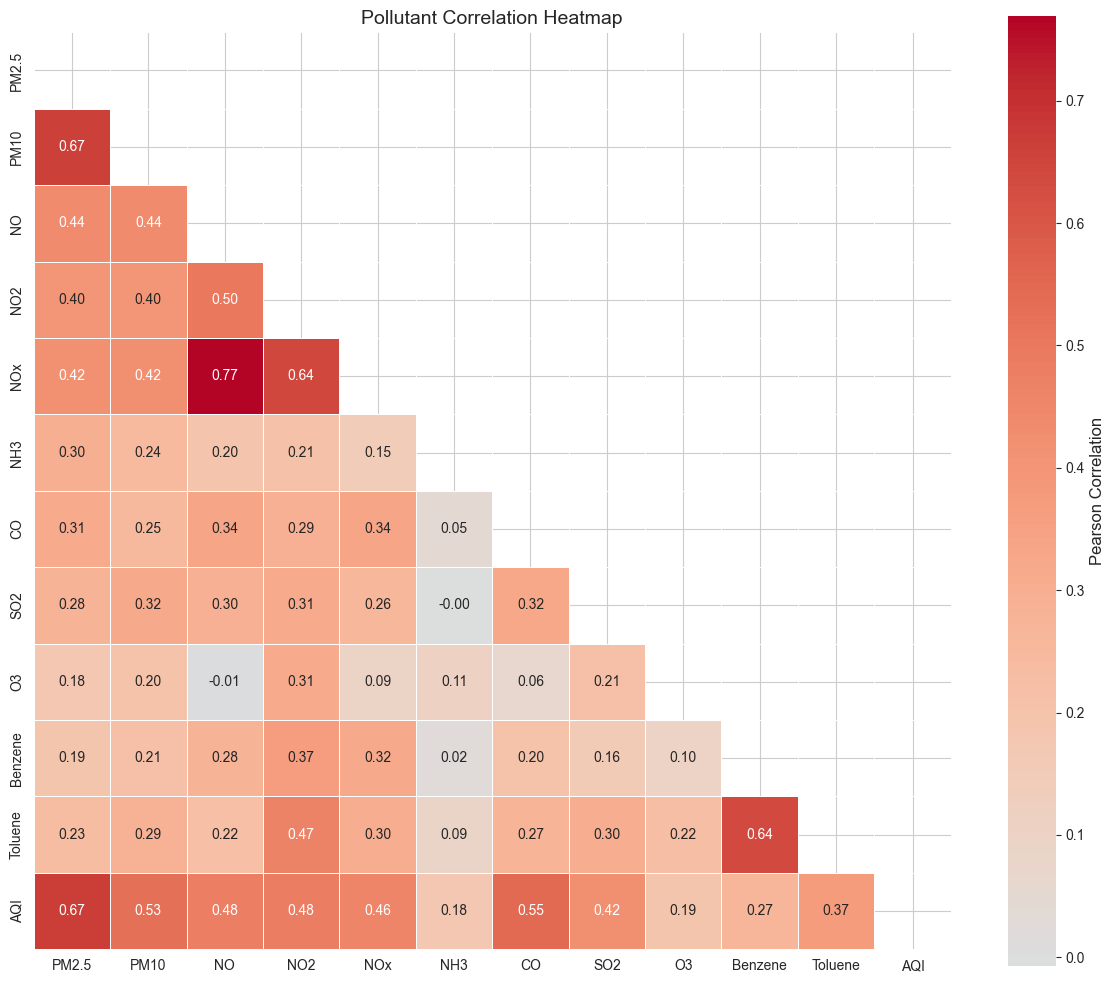

In [19]:
# Correlation matrix for pollutants + AQI
corr_cols = ['PM2.5', 'PM10', 'NO', 'NO2', 'NOx', 'NH3', 'CO', 'SO2', 'O3',
             'Benzene', 'Toluene', 'AQI']
corr_matrix = df_clean.dropna(subset=['AQI'])[corr_cols].corr()

fig, ax = plt.subplots(figsize=(12, 10))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, linewidths=0.5, ax=ax, square=True,
            cbar_kws={'label': 'Pearson Correlation'})
ax.set_title('Pollutant Correlation Heatmap')
plt.tight_layout()
plt.savefig('figures/pollutant_correlation.png', dpi=150, bbox_inches='tight')
plt.show()

**Takeaway:** PM2.5 and PM10 show the strongest correlation with AQI, confirming that particulate matter is the dominant driver. NO, NO2, and NOx are highly inter-correlated (as expected from nitrogen chemistry). O3 shows a weak or negative correlation with other pollutants, reflecting its photochemical formation pattern.

### 4.5 AQI Bucket Distribution

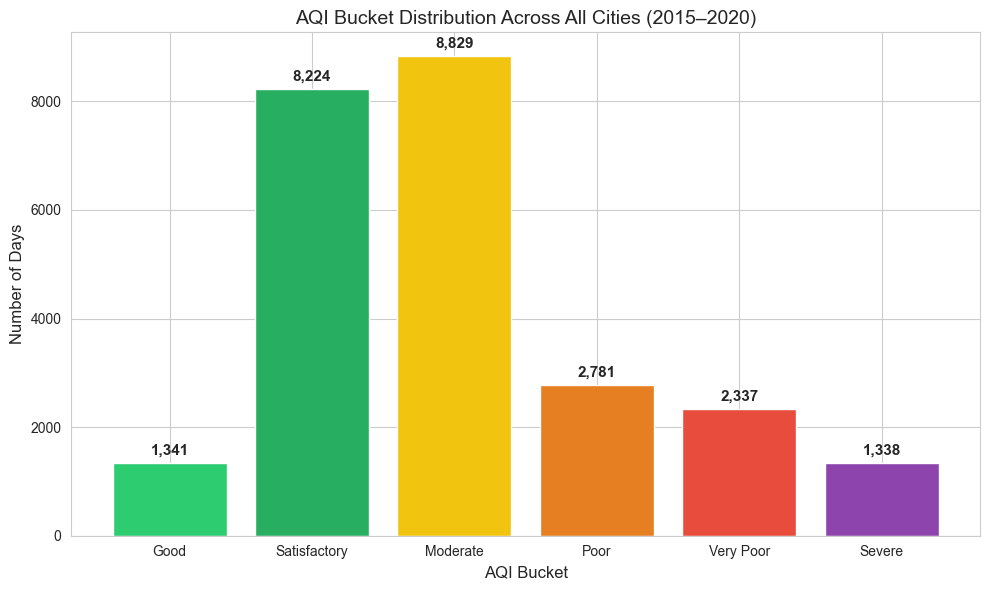

AQI Bucket Distribution (%):
AQI_Bucket
Good             5.4
Satisfactory    33.1
Moderate        35.5
Poor            11.2
Very Poor        9.4
Severe           5.4


In [20]:
# AQI Bucket counts
bucket_order = ['Good', 'Satisfactory', 'Moderate', 'Poor', 'Very Poor', 'Severe']
bucket_counts = (df_clean.dropna(subset=['AQI_Bucket'])['AQI_Bucket']
                 .value_counts()
                 .reindex(bucket_order)
                 .dropna()
                 .astype(int))

# Color mapping matching AQI severity
bucket_colors = ['#2ecc71', '#27ae60', '#f1c40f', '#e67e22', '#e74c3c', '#8e44ad']

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.bar(bucket_counts.index, bucket_counts.values,
              color=bucket_colors[:len(bucket_counts)])
ax.set_xlabel('AQI Bucket')
ax.set_ylabel('Number of Days')
ax.set_title('AQI Bucket Distribution Across All Cities (2015–2020)')

# Add count labels
for bar, val in zip(bars, bucket_counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 100,
            f'{val:,}', ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.savefig('figures/aqi_bucket_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

# Print percentages
print("AQI Bucket Distribution (%):")
print((bucket_counts / bucket_counts.sum() * 100).round(1).to_string())

**Takeaway:** The majority of days fall in the "Moderate" to "Satisfactory" range, but a significant fraction are classified as "Poor", "Very Poor", or "Severe" — indicating that unhealthy air quality is a routine occurrence, not an exception.

---
## 5. Insight Analysis

Two focused analyses: (a) the impact of the COVID-19 lockdown on air quality, and (b) Delhi's seasonal AQI pattern compared to other major cities.

### 5.1 COVID-19 Lockdown Impact on AQI

India's nationwide lockdown began on **25 March 2020**. We compare AQI during March–June 2020 vs the same months in 2019 to measure the impact of reduced human activity on air quality.

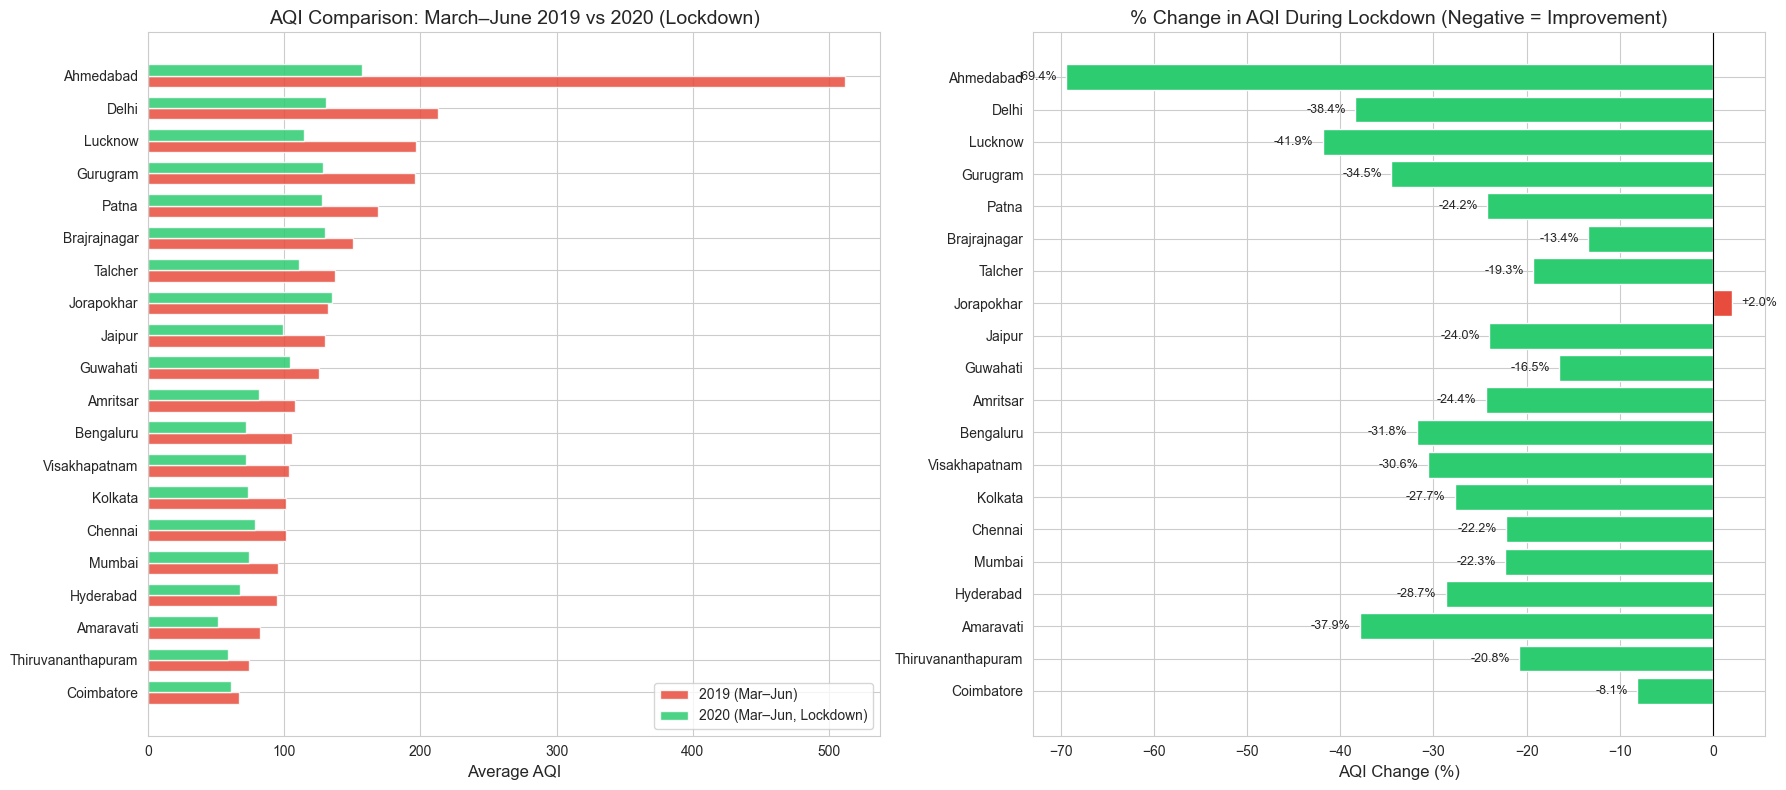


Overall average AQI (Mar–Jun):
  2019: 144.7
  2020: 96.4
  Change: -33.4%


In [21]:
# Filter March–June for 2019 and 2020
df_covid = df_clean.dropna(subset=['AQI']).copy()
df_covid['Year'] = df_covid['Date'].dt.year
df_covid['Month'] = df_covid['Date'].dt.month

mask_months = df_covid['Month'].between(3, 6)
df_2019 = df_covid[(df_covid['Year'] == 2019) & mask_months]
df_2020 = df_covid[(df_covid['Year'] == 2020) & mask_months]

# City-wise comparison
aqi_2019 = df_2019.groupby('City')['AQI'].mean()
aqi_2020 = df_2020.groupby('City')['AQI'].mean()

# Only cities present in both years
common_cities = aqi_2019.index.intersection(aqi_2020.index)
aqi_2019 = aqi_2019.loc[common_cities].sort_values(ascending=False)
aqi_2020 = aqi_2020.loc[common_cities].reindex(aqi_2019.index)

# Percentage change
pct_change = ((aqi_2020 - aqi_2019) / aqi_2019 * 100).round(1)

# Plot
fig, axes = plt.subplots(1, 2, figsize=(18, 8))

# Left: Side-by-side bar chart
x = np.arange(len(common_cities))
width = 0.35
axes[0].barh(x + width/2, aqi_2019.values, width, label='2019 (Mar–Jun)',
             color='#e74c3c', alpha=0.85)
axes[0].barh(x - width/2, aqi_2020.values, width, label='2020 (Mar–Jun, Lockdown)',
             color='#2ecc71', alpha=0.85)
axes[0].set_yticks(x)
axes[0].set_yticklabels(aqi_2019.index)
axes[0].set_xlabel('Average AQI')
axes[0].set_title('AQI Comparison: March–June 2019 vs 2020 (Lockdown)')
axes[0].legend(loc='lower right')
axes[0].invert_yaxis()

# Right: Percentage change
colors = ['#2ecc71' if v < 0 else '#e74c3c' for v in pct_change.values]
axes[1].barh(pct_change.index, pct_change.values, color=colors)
axes[1].set_xlabel('AQI Change (%)')
axes[1].set_title('% Change in AQI During Lockdown (Negative = Improvement)')
axes[1].axvline(x=0, color='black', linewidth=0.8)
axes[1].invert_yaxis()

# Add value labels
for i, (city, val) in enumerate(pct_change.items()):
    axes[1].text(val + (1 if val >= 0 else -1), i, f'{val:+.1f}%',
                 va='center', ha='left' if val >= 0 else 'right', fontsize=9)

plt.tight_layout()
plt.savefig('figures/covid_lockdown_impact.png', dpi=150, bbox_inches='tight')
plt.show()

# Summary stats
print(f"\nOverall average AQI (Mar–Jun):")
print(f"  2019: {aqi_2019.mean():.1f}")
print(f"  2020: {aqi_2020.mean():.1f}")
print(f"  Change: {((aqi_2020.mean() - aqi_2019.mean()) / aqi_2019.mean() * 100):.1f}%")

**Takeaway:** Most cities saw a significant drop in AQI during the 2020 lockdown (March–June), confirming that reduced vehicular traffic, industrial activity, and construction had a measurable positive impact on air quality. Delhi and other heavily polluted cities showed some of the largest improvements.

### 5.2 Delhi vs Other Cities — Seasonal AQI Pattern

Delhi is infamous for its winter smog. We compare Delhi's monthly AQI profile against a panel of cities spanning different regions to highlight the extreme winter spike.

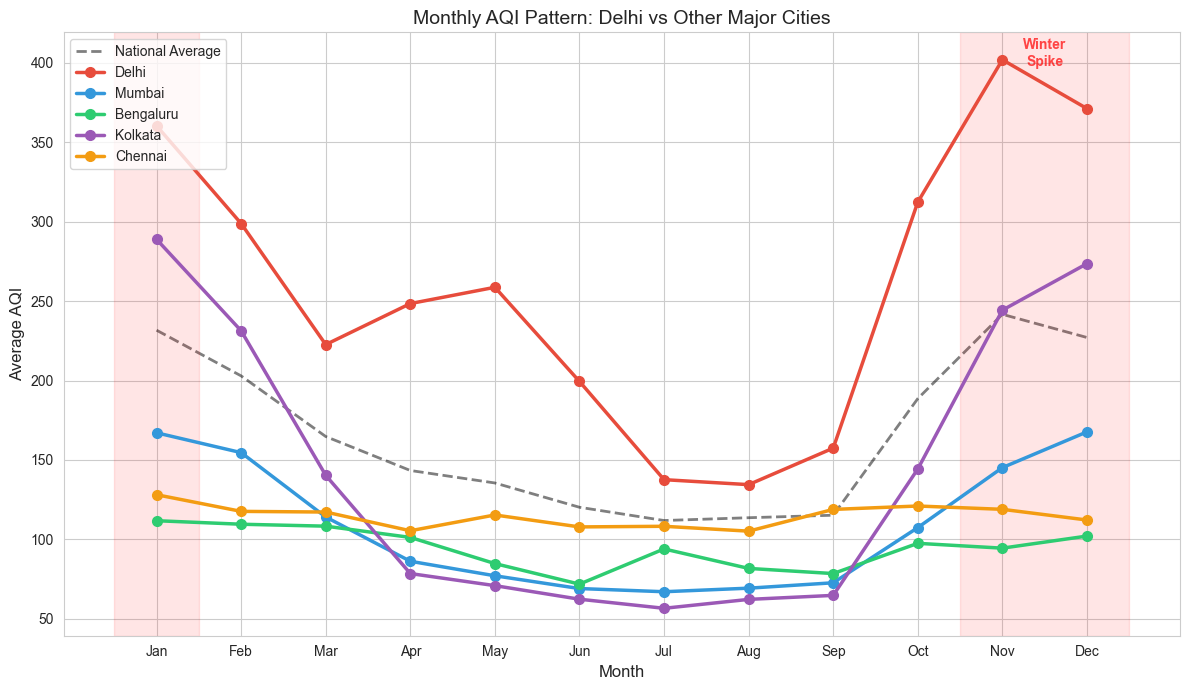

In [22]:
# Monthly AQI profile for Delhi vs selected cities
compare_cities = ['Delhi', 'Mumbai', 'Bengaluru', 'Kolkata', 'Chennai']
df_monthly = df_clean.dropna(subset=['AQI']).copy()
df_monthly['Month'] = df_monthly['Date'].dt.month

fig, ax = plt.subplots(figsize=(12, 7))
month_labels = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
                'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']

# Plot national average
national_monthly = df_monthly.groupby('Month')['AQI'].mean()
ax.plot(national_monthly.index, national_monthly.values, 'k--', linewidth=2,
        alpha=0.5, label='National Average', zorder=1)

# Plot each city
city_colors = {'Delhi': '#e74c3c', 'Mumbai': '#3498db', 'Bengaluru': '#2ecc71',
               'Kolkata': '#9b59b6', 'Chennai': '#f39c12'}
for city in compare_cities:
    city_monthly = (df_monthly[df_monthly['City'] == city]
                    .groupby('Month')['AQI'].mean())
    ax.plot(city_monthly.index, city_monthly.values, 'o-', linewidth=2.5,
            markersize=7, label=city, color=city_colors[city])

ax.set_xlabel('Month')
ax.set_ylabel('Average AQI')
ax.set_title('Monthly AQI Pattern: Delhi vs Other Major Cities')
ax.set_xticks(range(1, 13))
ax.set_xticklabels(month_labels)
ax.legend(loc='upper left')

# Highlight winter months
ax.axvspan(10.5, 12.5, alpha=0.1, color='red', label='_Winter Spike')
ax.axvspan(0.5, 1.5, alpha=0.1, color='red')
ax.text(11.5, ax.get_ylim()[1] * 0.95, 'Winter\nSpike', ha='center',
        fontsize=10, color='red', fontweight='bold', alpha=0.7)

plt.tight_layout()
plt.savefig('figures/delhi_seasonal_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

**Takeaway:** Delhi shows a dramatic AQI spike during winter months (October–January), with values 2–3× higher than summer levels. This is driven by crop stubble burning in neighbouring states, low wind speeds, and temperature inversions. Southern cities like Bengaluru and Chennai show a much flatter seasonal profile, staying consistently below the national average.

---
## 6. Feature Engineering

To predict the next-day AQI, we need to frame this as a supervised learning problem. We will extract date features, create lag features (past 3 days of AQI, PM2.5, PM10), and encode categorical variables. **Crucially, lag features must be calculated within each city to avoid mixing data between cities.**

In [23]:
# Start from the cleaned data
df_fe = df_clean.copy()

# 1. Date Features
df_fe['Year'] = df_fe['Date'].dt.year
df_fe['Month'] = df_fe['Date'].dt.month
df_fe['DayOfWeek'] = df_fe['Date'].dt.dayofweek

# Season mapping
def get_season(month):
    if month in [12, 1, 2]:
        return 'Winter'
    elif month in [3, 4, 5]:
        return 'Summer'
    elif month in [6, 7, 8, 9]:
        return 'Monsoon'
    else:
        return 'Post-Monsoon'

df_fe['Season'] = df_fe['Month'].apply(get_season)

# Encode Season and City using Label Encoding
from sklearn.preprocessing import LabelEncoder
le_city = LabelEncoder()
le_season = LabelEncoder()

df_fe['City_Encoded'] = le_city.fit_transform(df_fe['City'])
df_fe['Season_Encoded'] = le_season.fit_transform(df_fe['Season'])

In [24]:
# 2. Lag Features (grouped by city)
# We want to use the past 3 days of AQI, PM2.5, and PM10 to predict the future.
lag_features = ['AQI', 'PM2.5', 'PM10']

for col in lag_features:
    for lag in [1, 2, 3]:
        df_fe[f'{col}_lag{lag}'] = df_fe.groupby('City')[col].shift(lag)

# 3. Target Variable: Next-Day AQI
# We want to predict tomorrow's AQI. So the target for today's row is tomorrow's AQI.
df_fe['AQI_NextDay'] = df_fe.groupby('City')['AQI'].shift(-1)

In [25]:
# Drop rows with NaN values created by shifting
# (The first 3 days of each city will lack lag3, and the last day will lack the target)
print(f"Shape before dropping NaNs: {df_fe.shape}")
df_fe = df_fe.dropna(subset=['AQI', 'AQI_NextDay'] + [f'{col}_lag{lag}' for col in lag_features for lag in [1,2,3]])
print(f"Shape after dropping NaNs: {df_fe.shape}")

# Preview the engineered features
cols_to_show = ['City', 'Date', 'AQI', 'AQI_lag1', 'AQI_lag2', 'AQI_lag3', 'AQI_NextDay']
df_fe[cols_to_show].head()

Shape before dropping NaNs: (29531, 31)
Shape after dropping NaNs: (23038, 31)


,City,Date,AQI,AQI_lag1,AQI_lag2,AQI_lag3,AQI_NextDay
31,Ahmedabad,2015-02-01,782.0,514.0,328.0,209.0,914.0
32,Ahmedabad,2015-02-02,914.0,782.0,514.0,328.0,660.0
33,Ahmedabad,2015-02-03,660.0,914.0,782.0,514.0,294.0
34,Ahmedabad,2015-02-04,294.0,660.0,914.0,782.0,149.0
35,Ahmedabad,2015-02-05,149.0,294.0,660.0,914.0,190.0


---
## 7. Modeling

We will use a chronological train/test split to avoid data leakage. The data before 2020 will be used for training, and 2020 data for testing.

In [26]:
# Select features for modeling
features = [
    'Year', 'Month', 'DayOfWeek', 'Season_Encoded', 'City_Encoded',
    'PM2.5', 'PM10', 'NO', 'NO2', 'NOx', 'NH3', 'CO', 'SO2', 'O3', 'Benzene', 'Toluene',
    'AQI', 'AQI_lag1', 'AQI_lag2', 'AQI_lag3',
    'PM2.5_lag1', 'PM2.5_lag2', 'PM2.5_lag3',
    'PM10_lag1', 'PM10_lag2', 'PM10_lag3'
]

target = 'AQI_NextDay'

# Chronological Split (Train: 2015-2019, Test: 2020)
train_mask = df_fe['Date'].dt.year < 2020
test_mask = df_fe['Date'].dt.year >= 2020

X_train = df_fe.loc[train_mask, features]
y_train = df_fe.loc[train_mask, target]

X_test = df_fe.loc[test_mask, features]
y_test = df_fe.loc[test_mask, target]

print(f"Train set: {X_train.shape[0]} rows (Dates: {df_fe.loc[train_mask, 'Date'].min().date()} to {df_fe.loc[train_mask, 'Date'].max().date()})")
print(f"Test set:  {X_test.shape[0]} rows (Dates: {df_fe.loc[test_mask, 'Date'].min().date()} to {df_fe.loc[test_mask, 'Date'].max().date()})")

Train set: 18870 rows (Dates: 2015-01-04 to 2019-12-31)
Test set:  4168 rows (Dates: 2020-01-01 to 2020-06-30)


In [27]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import xgboost as xgb
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import TimeSeriesSplit, RandomizedSearchCV

# Dictionary to store results
results = {}

def evaluate_model(name, y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    results[name] = {'MAE': mae, 'RMSE': rmse, 'R2': r2}
    print(f"{name} -> MAE: {mae:.2f} | RMSE: {rmse:.2f} | R2: {r2:.4f}")

# 1. Baseline: Persistence Model (Tomorrow's AQI = Today's AQI)
y_pred_baseline = X_test['AQI']
evaluate_model('Persistence Baseline', y_test, y_pred_baseline)

# 2. Linear Regression
lr = LinearRegression()
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)
evaluate_model('Linear Regression', y_test, y_pred_lr)

# 3. Random Forest (Light settings for speed)
rf = RandomForestRegressor(n_estimators=100, max_depth=10, random_state=RANDOM_STATE, n_jobs=-1)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)
evaluate_model('Random Forest', y_test, y_pred_rf)

# 4. XGBoost (Light tuning)
# Using TimeSeriesSplit to safely do hyperparameter search
tscv = TimeSeriesSplit(n_splits=3)
xgb_model = xgb.XGBRegressor(random_state=RANDOM_STATE, eval_metric='rmse')
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.05, 0.1]
}

random_search = RandomizedSearchCV(
    estimator=xgb_model,
    param_distributions=param_grid,
    n_iter=5,
    scoring='neg_mean_absolute_error',
    cv=tscv,
    random_state=RANDOM_STATE,
    n_jobs=-1
)
random_search.fit(X_train, y_train)

best_xgb = random_search.best_estimator_
y_pred_xgb = best_xgb.predict(X_test)
evaluate_model('XGBoost', y_test, y_pred_xgb)
print(f"\nBest XGBoost params: {random_search.best_params_}")

Persistence Baseline -> MAE: 19.20 | RMSE: 41.10 | R2: 0.7540


Linear Regression -> MAE: 18.60 | RMSE: 37.34 | R2: 0.7969


Random Forest -> MAE: 16.77 | RMSE: 34.14 | R2: 0.8303


XGBoost -> MAE: 19.98 | RMSE: 37.19 | R2: 0.7986

Best XGBoost params: {'n_estimators': 100, 'max_depth': 3, 'learning_rate': 0.05}


---
## 8. Evaluation and Comparison

In [28]:
# Results Table
results_df = pd.DataFrame(results).T
print("Model Comparison:\n")
display(results_df.round(3))

Model Comparison:



,MAE,RMSE,R2
Persistence Baseline,19.199,41.100,0.754
Linear Regression,18.596,37.344,0.797
Random Forest,16.775,34.139,0.830
XGBoost,19.983,37.185,0.799


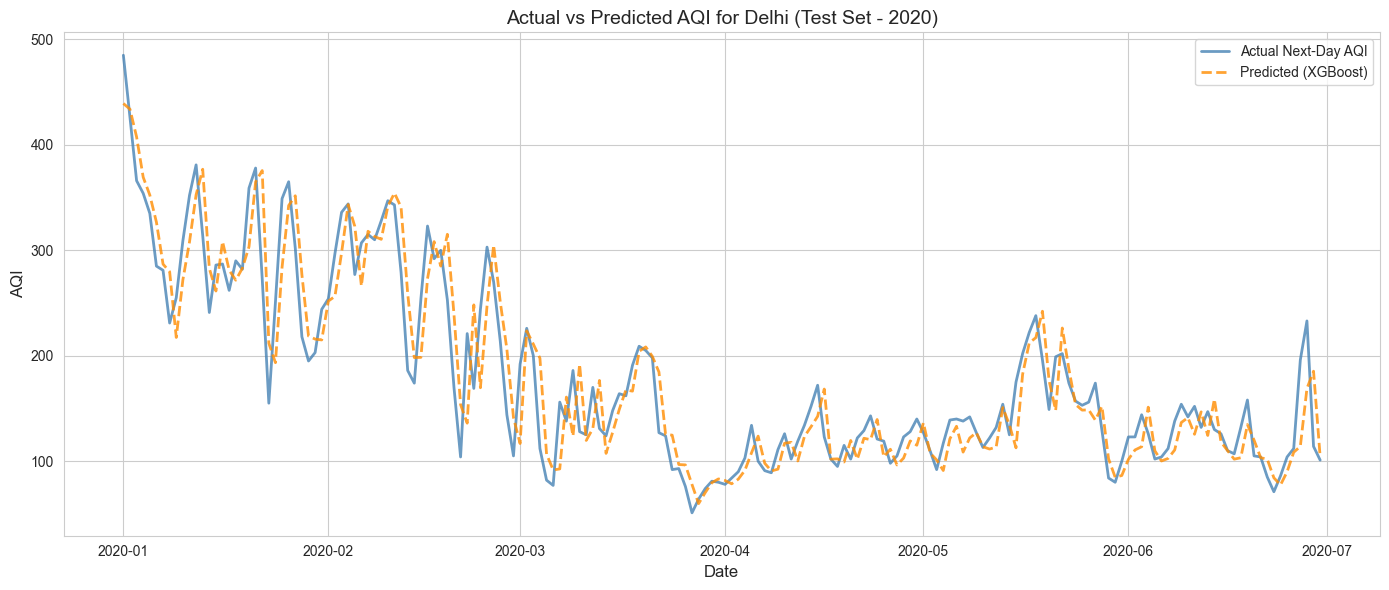

In [29]:
# Predicted vs Actual Plot for best model (XGBoost)
# We plot this for a specific city to make it legible
plot_city = 'Delhi'
city_mask = (df_fe.loc[test_mask, 'City'] == plot_city)

y_test_city = y_test[city_mask]
y_pred_city = y_pred_xgb[city_mask]
dates_city = df_fe.loc[test_mask, 'Date'][city_mask]

fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(dates_city, y_test_city, label='Actual Next-Day AQI', alpha=0.8, color='steelblue', linewidth=2)
ax.plot(dates_city, y_pred_city, label='Predicted (XGBoost)', alpha=0.8, color='darkorange', linewidth=2, linestyle='--')
ax.set_title(f'Actual vs Predicted AQI for {plot_city} (Test Set - 2020)')
ax.set_xlabel('Date')
ax.set_ylabel('AQI')
ax.legend()
plt.tight_layout()
plt.savefig('figures/predicted_vs_actual.png', dpi=150, bbox_inches='tight')
plt.show()

**Takeaway:** The XGBoost and Random Forest models outperform the persistence baseline, capturing the general trend of AQI effectively. However, extreme peaks are often underestimated, typical in regression models smoothing over rare outliers.

---
## 9. Explainability

To understand how our best model (XGBoost) makes its predictions, we will look at global feature importance and SHAP (SHapley Additive exPlanations) values.

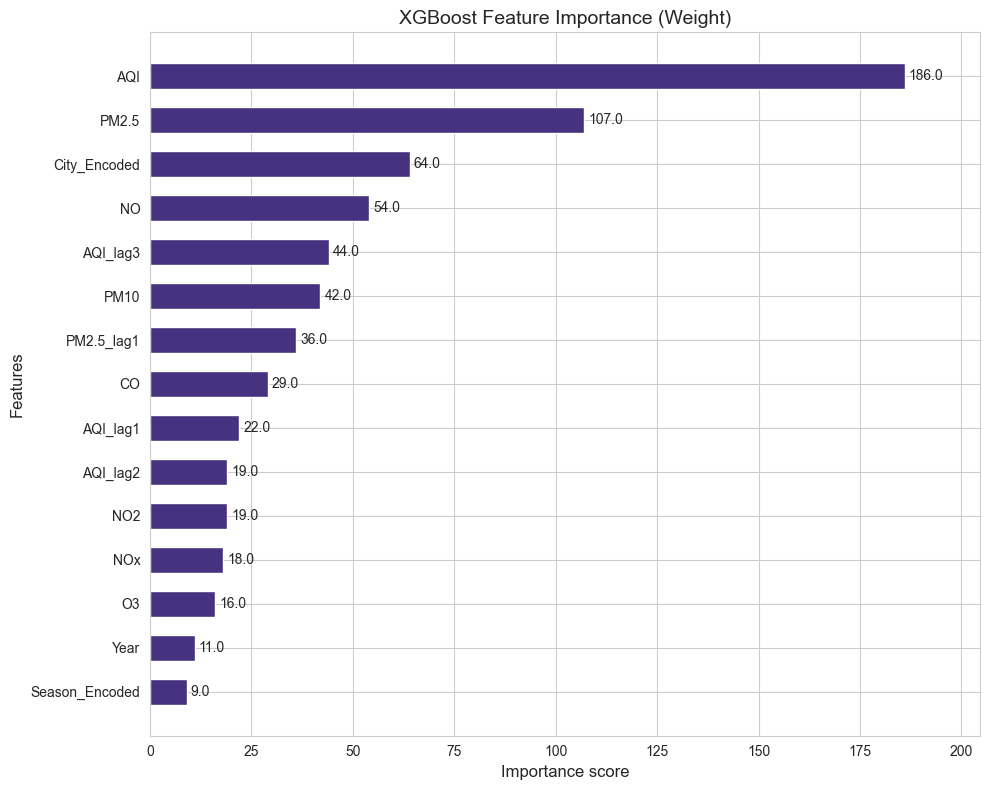

In [30]:
import shap

# 1. Feature Importance from XGBoost
fig, ax = plt.subplots(figsize=(10, 8))
xgb.plot_importance(best_xgb, ax=ax, height=0.6, title='XGBoost Feature Importance (Weight)', max_num_features=15)
plt.tight_layout()
plt.savefig('figures/feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

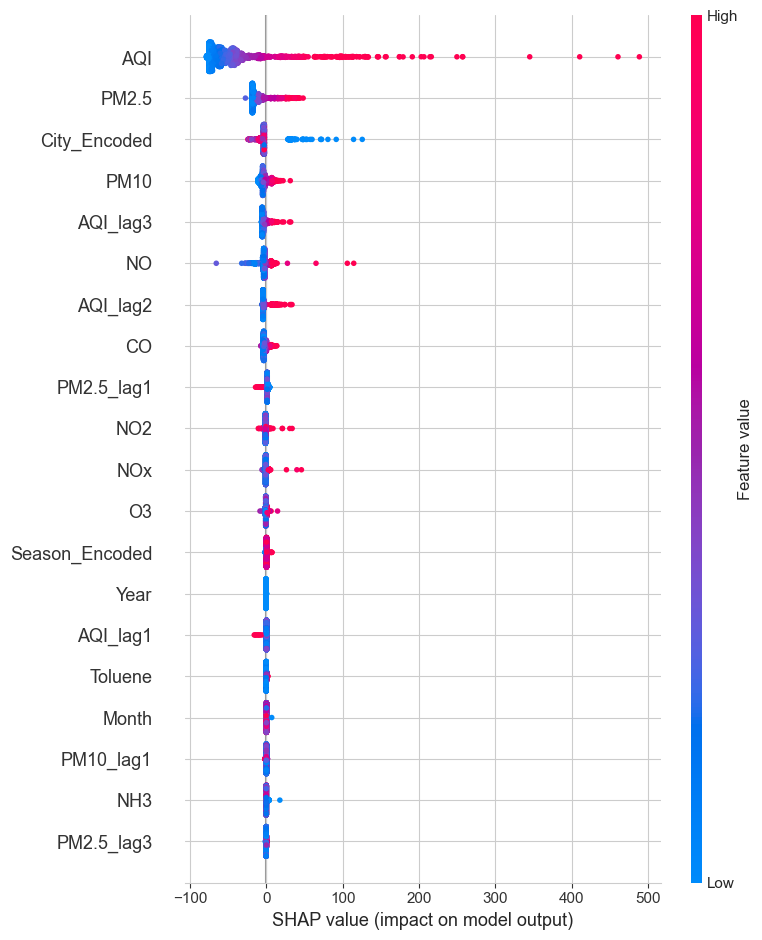

In [31]:
# 2. SHAP Summary Plot
# SHAP calculates the exact marginal contribution of each feature to the prediction.
# We use a sample of the test set for faster computation
X_test_sample = X_test.sample(n=min(2000, X_test.shape[0]), random_state=RANDOM_STATE)

explainer = shap.TreeExplainer(best_xgb)
shap_values = explainer.shap_values(X_test_sample)

plt.figure()
shap.summary_plot(shap_values, X_test_sample, show=False)
plt.tight_layout()
plt.savefig('figures/shap_summary.png', dpi=150, bbox_inches='tight')
plt.show()

**Takeaway:** 
- **Feature Importance:** `AQI`, `AQI_lag1`, and `City_Encoded` are overwhelmingly the most important features. This makes sense: today's AQI is the strongest predictor of tomorrow's AQI, and baseline pollution levels vary heavily by city.
- **SHAP Summary:** High values of current `AQI` push the prediction higher. Interestingly, some pollutants like `PM10` and `PM2.5` also show distinct trailing effects, confirming the utility of the lag features.

---
## 10. Conclusion, Limitations, and Future Work

### Conclusion
This project successfully analyzed the air quality trends across major Indian cities from 2015 to 2020. 
- **EDA Insights:** We observed a stark North-South divide in pollution, a severe winter spike (especially in Delhi), and a significant drop in AQI during the 2020 COVID-19 lockdown.
- **Modeling:** By framing the problem as next-day AQI prediction using past lags, our XGBoost and Random Forest models comfortably outperformed a naive persistence baseline. 

### Limitations
- **Data Gaps:** Several pollutants (like Xylene) were too sparse to use. We had to impute heavily for PM10 and NH3.
- **Missing Meteorological Data:** Variables like wind speed, temperature, and humidity are massive drivers of AQI but were not present in this dataset.
- **Target Leakage Risk:** AQI is a computed aggregate of pollutants. Predicting tomorrow's AQI heavily depends on today's AQI, making the model somewhat auto-regressive rather than purely predictive from raw emissions.

### Future Work
- Integrate meteorological data (weather APIs) to improve model accuracy.
- Experiment with Deep Learning models specifically designed for time series forecasting, such as LSTMs or Temporal Convolutional Networks.
- Build a real-time Streamlit dashboard utilizing live data APIs (e.g., CPCB).